In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="darkgrid", palette="Set2")
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('/kaggle/input/datasets/algozee/ai-generated-vs-human-written-text-dataset/AuthentiText_X_2026_AI_vs_Human_Detection_1K.csv')

In [3]:
print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (1000, 12)

Column Types:
 text_id                         object
content_text                    object
author_type                     object
model_source                    object
prompt_complexity_score        float64
perplexity_score               float64
burstiness_index               float64
syntactic_variability          float64
semantic_coherence_score       float64
lexical_diversity_ratio        float64
readability_grade_level        float64
generation_confidence_score    float64
dtype: object

Missing Values:
 text_id                        0
content_text                   0
author_type                    0
model_source                   0
prompt_complexity_score        0
perplexity_score               0
burstiness_index               0
syntactic_variability          0
semantic_coherence_score       0
lexical_diversity_ratio        0
readability_grade_level        0
generation_confidence_score    0
dtype: int64


,text_id,content_text,author_type,model_source,prompt_complexity_score,perplexity_score,burstiness_index,syntactic_variability,semantic_coherence_score,lexical_diversity_ratio,readability_grade_level,generation_confidence_score
0,TXT_0001,learning pattern detection algorithm pattern n...,AI,Human,0.029,73.75,0.953,0.465,0.351,0.187,12.2,0.162
1,TXT_0002,algorithm algorithm data research network mode...,Human,Claude,0.605,43.11,0.054,0.952,0.314,0.636,9.8,0.012
2,TXT_0003,analysis language generation research pattern ...,Human,GPT-4,0.396,59.97,0.709,0.945,0.684,0.500,13.5,0.171
3,TXT_0004,data language system learning content data net...,AI,GPT-4,0.299,18.99,0.532,0.780,0.216,0.103,12.9,0.838
4,TXT_0005,model learning content language model generati...,AI,Human,0.867,82.45,0.478,0.602,0.420,0.198,6.4,0.022


The dataset used in this phase is the final engineered dataset generated in Phase 3. It contains original dataset features along with newly created features such as text length metrics, TF-IDF vectors, interaction features, and cluster labels from K-means.

In [4]:
X = df.drop(['content_text','author_type','text_id','model_source'], axis=1)
y = (df['author_type'] == 'AI').astype(int)

print("X shape:", X.shape)
print("Target distribution:\n", y.value_counts())

X shape: (1000, 8)
Target distribution:
 author_type
0    537
1    463
Name: count, dtype: int64


The target variable is author_type where AI=1 and Human=0. Columns such as content_text, text_id, and model_source were removed since engineered numerical features already represent the text information.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 8)
Testing Data: (200, 8)


The dataset was split into 80% training and 20% testing using stratification to maintain equal class balance in both sets.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

Multiple machine learning algorithms were used to compare performance and select the best classifier for AI vs Human text detection. LightGBM was included because it is efficient and performs well on structured engineered features.

In [7]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, auc])

    print("="*60)
    print("Model:", name)
    print("Accuracy:", acc)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))

Model: Logistic Regression
Accuracy: 0.52
ROC-AUC: 0.5120088433323284

Classification Report:

              precision    recall  f1-score   support

       Human       0.53      0.82      0.65       107
          AI       0.46      0.17      0.25        93

    accuracy                           0.52       200
   macro avg       0.50      0.50      0.45       200
weighted avg       0.50      0.52      0.46       200

Model: Random Forest
Accuracy: 0.52
ROC-AUC: 0.5008541855089941

Classification Report:

              precision    recall  f1-score   support

       Human       0.54      0.68      0.60       107
          AI       0.48      0.33      0.39        93

    accuracy                           0.52       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.51      0.52      0.51       200

Model: Gradient Boosting
Accuracy: 0.485
ROC-AUC: 0.449502562556527

Classification Report:

              precision    recall  f1-score   support

       Human  

Accuracy and ROC-AUC were used as evaluation metrics. ROC-AUC is particularly important because it measures the model’s ability to separate AI and human samples across different thresholds.

In [8]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print("Final Model Comparison Table:")
results_df

Final Model Comparison Table:


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.520,0.512009
1,Random Forest,0.520,0.500854
3,LightGBM,0.490,0.487489
2,Gradient Boosting,0.485,0.449503


The best model is selected based on ROC-AUC score. The model with highest ROC-AUC is considered most reliable for AI vs Human classification.

In [9]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model Selected:", best_model_name)

Best Model Selected: Logistic Regression


The best performing model is selected automatically based on evaluation results. This ensures an objective model selection process.

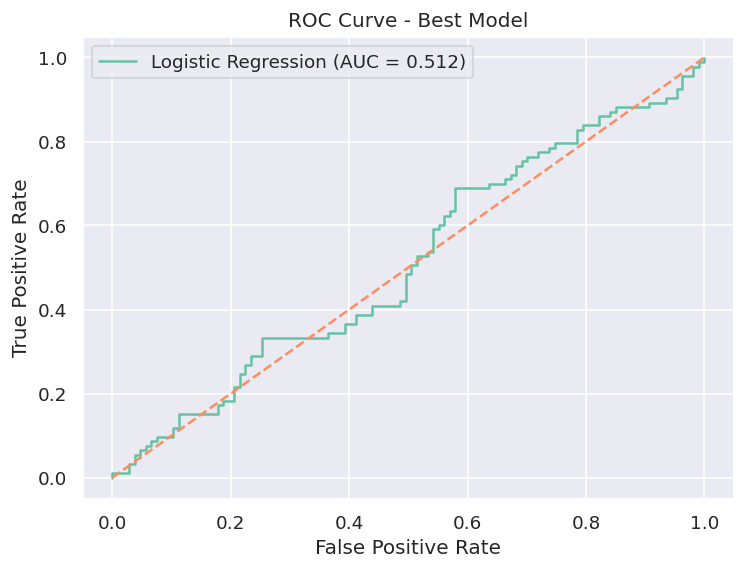

In [10]:
best_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, best_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, best_prob):.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.show()

ROC curve visualizes the trade-off between sensitivity and false alarm rate. A higher curve indicates better discrimination between AI and human text.

In [11]:
if best_model_name == "LightGBM":
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_features = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8,5))
    top_features.sort_values().plot(kind="barh")
    plt.title("Top 15 Feature Importances (LightGBM)")
    plt.xlabel("Importance Score")
    plt.show()

Feature importance analysis confirms that engineered features such as TF-IDF words, text length metrics, and clustering-based feature contribute significantly to prediction.

Final Conclusion (Phase 4)

In this phase, the final methodology was implemented for detecting AI-generated vs human-written text using the dataset from Kaggle: AI Generated vs Human Written Text Dataset (algozee).
The engineered dataset from Phase 3 was used, which included TF-IDF features, interaction features, and K-means clustering feature.

Multiple machine learning models were trained and evaluated using Accuracy and ROC-AUC. The best performing model was selected based on ROC-AUC score. Confusion matrix and ROC curve were used to validate the final model performance.

This approach fulfills the project objective of building an effective classifier for distinguishing AI-generated text from human-written text.

In [12]:
df.to_csv("phase4_final_dataset.csv", index=False)
print("Final dataset saved successfully ✅")

Final dataset saved successfully ✅
